In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2025-09-07_17-27-18/saved/checkpoint-epoch5000.npy", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(-403370.22), 'log_w': np.float32(403370.22)}

In [19]:
for data, target, indices in objects['datamodule'].test_dataloader():
    trace = objects['monad'](data)
    recons = trace['x'].mean(axis=0).reshape(data.shape[0], 1, 50, 50)
    z_where = trace['z_where'].mean(axis=0)
    break

In [20]:
def z_where_inv(z_where):
    # Take a batch of z_where vectors, and compute their "inverse".
    # That is, for each row compute:
    # [s,x,y] -> [1/s,-x/s,-y/s]
    # These are the parameters required to perform the inverse of the
    # spatial transform performed in the generative model.
    s = z_where[0]
    return np.array([1 / s, -z_where[1] / s, -z_where[2] / s]).T

def bounding_box(z_where, x_side):
    """This doesn't take into account interpolation, but it's close
    enough to be usable."""
    w = x_side / z_where[0]
    h = x_side / z_where[0]
    xtrans = z_where[1] / z_where[0] * x_side / 2.0
    ytrans = z_where[2] / z_where[0] * x_side / 2.0
    x = (x_side - w) / 2 + xtrans  # origin is top left
    y = (x_side - h) / 2 + ytrans
    return (x, y), w, h

def colors(k):
    return np.array([(1, 0, 0), (0, 1, 0), (0, 0, 1)])[k % 3]

def draw_z_where(z_where, x_side, k=0):
    import matplotlib.patches as patches
    ax = plt.gca()
    rect = patches.Rectangle(*bounding_box(z_where, x_side), edgecolor=colors(k), facecolor=[0, 0, 0, 0], linewidth=2)
    ax.add_patch(rect)

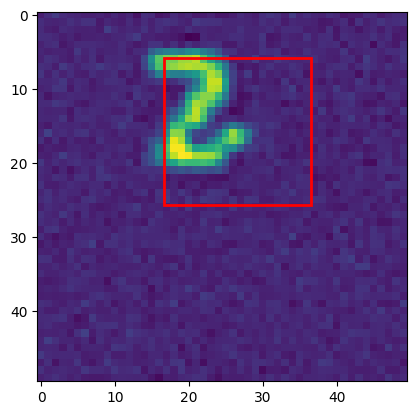

In [21]:
plt.imshow(recons[0].squeeze())
draw_z_where(z_where[0], recons[0].shape[-1])

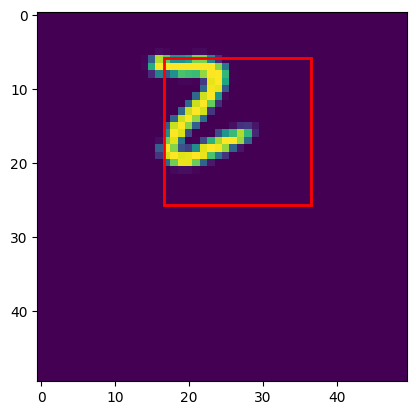

In [22]:
plt.imshow(data[0].squeeze())
draw_z_where(z_where[0], recons[0].shape[-1])

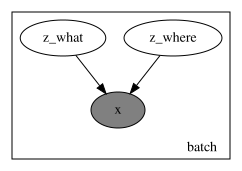

In [23]:
objects['monad'].render_model()